## **Step 1 : Load the graph and visualize it**


Nodes: 34
Edges: 78
Is directed: False
{0: 'Mr. Hi', 1: 'Mr. Hi', 2: 'Mr. Hi', 3: 'Mr. Hi', 4: 'Mr. Hi', 5: 'Mr. Hi', 6: 'Mr. Hi', 7: 'Mr. Hi', 8: 'Mr. Hi', 9: 'Officer', 10: 'Mr. Hi', 11: 'Mr. Hi', 12: 'Mr. Hi', 13: 'Mr. Hi', 14: 'Officer', 15: 'Officer', 16: 'Mr. Hi', 17: 'Mr. Hi', 18: 'Officer', 19: 'Mr. Hi', 20: 'Officer', 21: 'Mr. Hi', 22: 'Officer', 23: 'Officer', 24: 'Officer', 25: 'Officer', 26: 'Officer', 27: 'Officer', 28: 'Officer', 29: 'Officer', 30: 'Officer', 31: 'Officer', 32: 'Officer', 33: 'Officer'}


/tmp/ipykernel_2609/1607727007.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


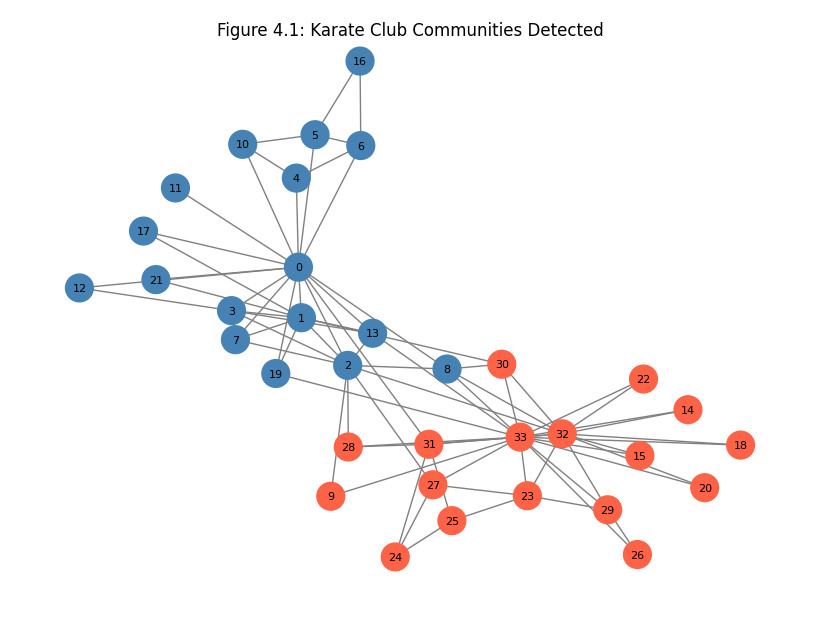

In [2]:
import networkx as nx # library for short nickname
import matplotlib.pyplot as plt # plotting library
import matplotlib.cm as cm # access to colormaps


# Load the Karate Club graph
G = nx.karate_club_graph()

# basic info
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Is directed: {G.is_directed()}")


# attributes is a node attribute
# "Mr.Hi" = faction 0, "John A" = faction 1
ground_truth = nx.get_node_attributes(G, 'club')
print(ground_truth)

# assign colors based on attributes
color_map = ["steelblue" if ground_truth[node] == "Mr. Hi"
             else "tomato" for node in G.nodes()] # belongs to John A


# visualize
pos = nx.spring_layout(G, seed = 1)
plt.figure(figsize=(8,6))
nx.draw(G, pos, node_color=color_map, with_labels=True, node_size=400, edge_color="gray", font_size=8)
plt.suptitle("Figure 4.1: Karate Club Communities Detected")
plt.tight_layout()
plt.savefig('/content/figure_4_1_karate_communities.png', dpi=300, bbox_inches='tight')
plt.show()

## **Step 2: Run three community detection methods**

In [4]:
import importlib # Import importlib to reload modules
from cdlib import algorithms, evaluation # algorithms contains all the community detection methods and evaluation contains the metrics like NMI and ARI.
from cdlib.classes.node_clustering import NodeClustering # that cdlib uses to represent a set of communities

# run three methods
louvain = algorithms.louvain(G)
infomap = algorithms.infomap(G)
walktrap = algorithms.walktrap(G)

# print the communities found
print("Louvain: ", louvain.communities)
print("Infomap: ", infomap.communities)
print("Walktrap: ", walktrap.communities)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.2 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'bayanpy', 'leidenalg', 'graph_tool', 'wurlitzer'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'wurlitzer', 'infomap'}
Louvain:  [[9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33], [0, 4, 5, 6, 10, 11, 16, 17, 19, 21], [1, 2, 3, 7, 8, 12, 13, 30]]
Infomap:  [[8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [0, 1, 2, 3, 7, 9, 11, 12, 13, 17, 19, 21], [4, 5, 6, 10, 16]]
W

## **Step 3: Build the ground truth in cdlib format and evaluate**



In [5]:
# convert ground truth to cdlib format
# we need a list of sets, one per community
faction_0 = [n for n, club in ground_truth.items() if club == 'Mr. Hi']
faction_1 = [n for n, club in ground_truth.items() if club == 'Officer']

gt = NodeClustering(
    communities=[faction_0, faction_1],
    graph=G,
    method_name="ground_truth"
)

# compute NMI for each method
nmi_louvain = evaluation.normalized_mutual_information(gt, louvain)
nmi_infomap = evaluation.normalized_mutual_information(gt, infomap)
nmi_walktrap = evaluation.normalized_mutual_information(gt, walktrap)

print(f"NMI for Louvain: {nmi_louvain.score:.4f}")
print(f"NMI for Infomap: {nmi_infomap.score:.4f}")
print(f"NMI for Walktrap: {nmi_walktrap.score:.4f}")

# ARI for each method
ari_louvain  = evaluation.adjusted_rand_index(gt, louvain)
ari_infomap  = evaluation.adjusted_rand_index(gt, infomap)
ari_walktrap = evaluation.adjusted_rand_index(gt, walktrap)

print(f"\nARI Louvain:  {ari_louvain.score:.4f}")
print(f"ARI Infomap:  {ari_infomap.score:.4f}")
print(f"ARI Walktrap: {ari_walktrap.score:.4f}")

NMI for Louvain: 0.6915
NMI for Infomap: 0.5684
NMI for Walktrap: 0.4899

ARI Louvain:  0.6653
ARI Infomap:  0.5906
ARI Walktrap: 0.3207


In [6]:
# check what the 4 communities actually are
for i, community in enumerate(louvain.communities): # i=0, i=1, i=2 ....
    print(f"\nLouvain community {i}:")
    print(f"  nodes: {sorted(community)}")
    factions = [ground_truth[n] for n in community]
    print(f"  factions: {set(factions)}")


Louvain community 0:
  nodes: [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33]
  factions: {'Officer'}

Louvain community 1:
  nodes: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
  factions: {'Mr. Hi'}

Louvain community 2:
  nodes: [1, 2, 3, 7, 8, 12, 13, 30]
  factions: {'Officer', 'Mr. Hi'}


## **Step 4: Visualize the detected communities with mixed one highlighted**

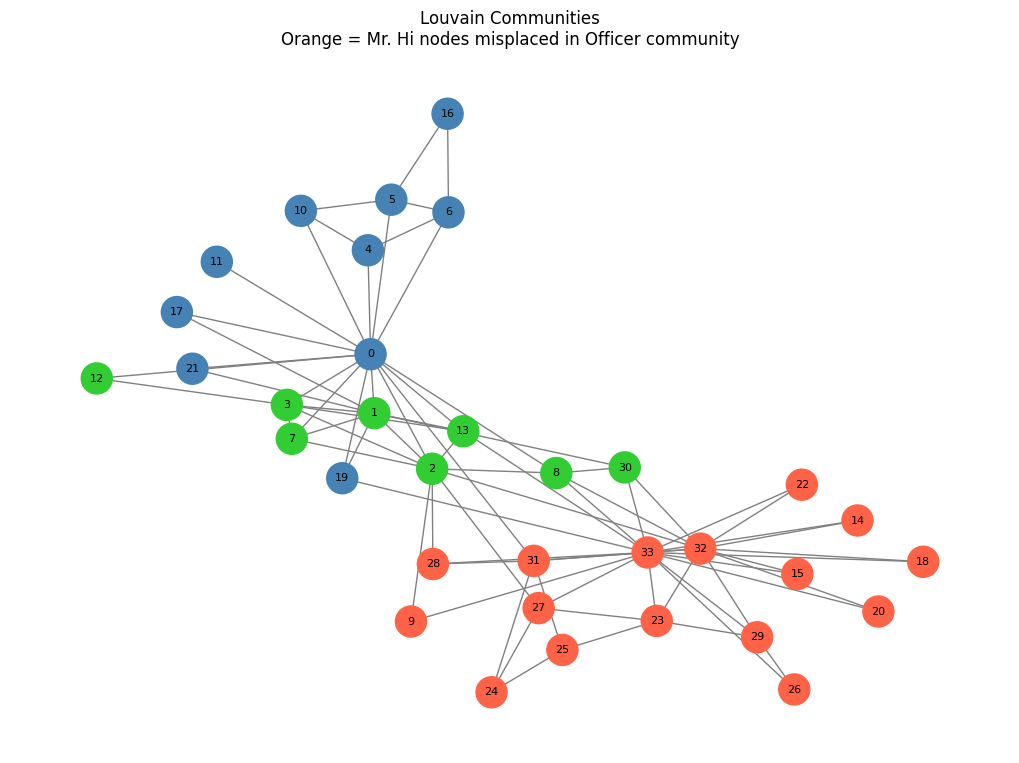

Mr. Hi nodes misplaced in Officer community: []
Number of misclassified nodes: 0


In [7]:
community_colors = []
for node in G.nodes():
  if node in louvain.communities[0]: # This is the mixed community
    if ground_truth[node] == "Mr. Hi":
      community_colors.append("orange") # misclassified Mr. Hi
    else: # ground_truth[node] == "Officer"
      community_colors.append("tomato") # correct John A
  elif node in louvain.communities[1]: # This community is entirely Mr. Hi
    community_colors.append("steelblue") # correct Mr. Hi
  elif node in louvain.communities[2]: # This community is entirely Officer
    community_colors.append("limegreen") # correct John A
  else: # This implicitly means node in louvain.communities[3], which is also Mr. Hi
    community_colors.append("lightblue") # correct Mr. Hi sub-group

plt.figure(figsize=(10,7))
nx.draw(G, pos, node_color=community_colors, with_labels=True, node_size=500, edge_color="gray", font_size=8)
plt.title("Louvain Communities\nOrange = Mr. Hi nodes misplaced in Officer community")
plt.show()

# identify exactly which Mr. Hi nodes are in the mixed community
misclassified = [n for n in louvain.communities[0]
                 if ground_truth[n] == "Mr. Hi"]
print(f"Mr. Hi nodes misplaced in Officer community: {misclassified}")
print(f"Number of misclassified nodes: {len(misclassified)}")

## **Step 5: Same examination for Walktrap and Infomap**

In [8]:
# check what the 3 communities actually are
print("--- INFOMAP ---")
for i, community in enumerate(infomap.communities): # i=0, i=1, i=2 ....
    print(f"\nInfomap community {i}:")
    print(f"  nodes: {sorted(community)}")
    factions = [ground_truth[n] for n in community]
    print(f"  factions: {set(factions)}")

# check what the 5 communities actually are
print("\n\n--- WALKTRAP ---")
for i, community in enumerate(walktrap.communities): # i=0, i=1, i=2 ....
    print(f"\nInfomap community {i}:")
    print(f"  nodes: {sorted(community)}")
    factions = [ground_truth[n] for n in community]
    print(f"  factions: {set(factions)}")

--- INFOMAP ---

Infomap community 0:
  nodes: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
  factions: {'Officer', 'Mr. Hi'}

Infomap community 1:
  nodes: [0, 1, 2, 3, 7, 9, 11, 12, 13, 17, 19, 21]
  factions: {'Officer', 'Mr. Hi'}

Infomap community 2:
  nodes: [4, 5, 6, 10, 16]
  factions: {'Mr. Hi'}


--- WALKTRAP ---

Infomap community 0:
  nodes: [0, 1, 3, 7, 11, 12, 17, 19, 21]
  factions: {'Mr. Hi'}

Infomap community 1:
  nodes: [14, 15, 18, 20, 22, 26, 29, 32, 33]
  factions: {'Officer'}

Infomap community 2:
  nodes: [2, 8, 9, 13, 28, 30, 31]
  factions: {'Officer', 'Mr. Hi'}

Infomap community 3:
  nodes: [4, 5, 6, 10, 16]
  factions: {'Mr. Hi'}

Infomap community 4:
  nodes: [23, 24, 25, 27]
  factions: {'Officer'}


## **Step 6: Visualize the detected communities with mixed one highlighted for Infomap and Walktrap**

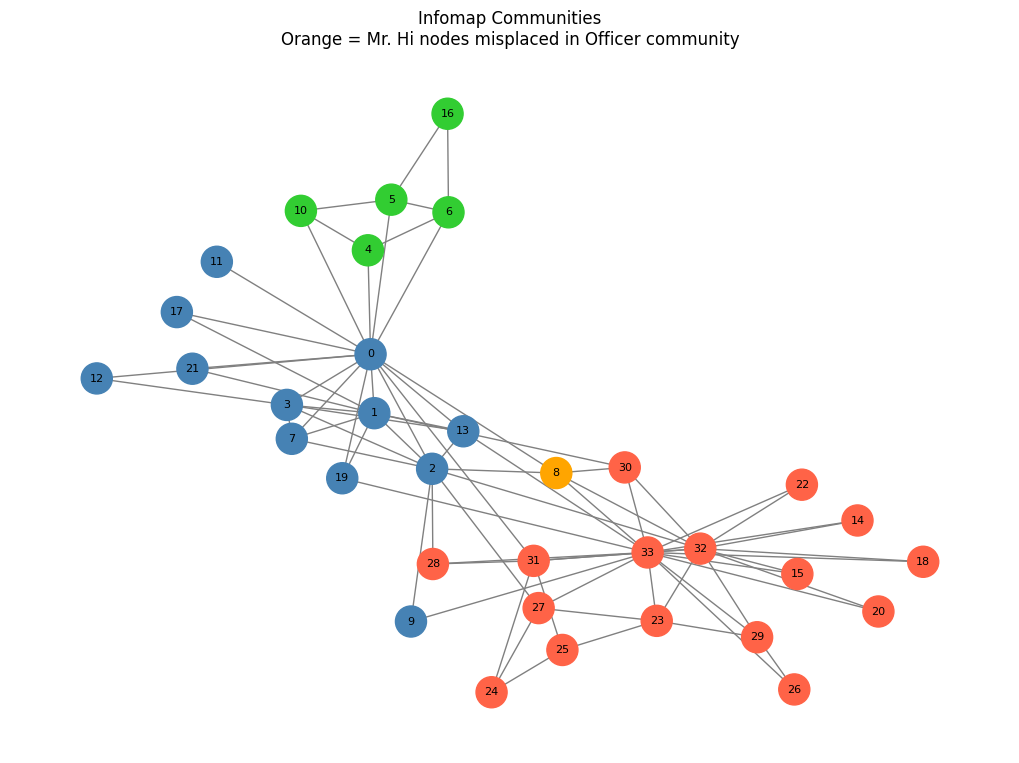

Mr. Hi nodes misplaced in Officer community: [8]
Number of misclassified nodes: 1


In [9]:
community_colors = []
for node in G.nodes():
  if node in infomap.communities[0]: # This is the mixed community
    if ground_truth[node] == "Mr. Hi":
      community_colors.append("orange") # misclassified Mr. Hi
    else: # ground_truth[node] == "Officer"
      community_colors.append("tomato") # correct John A
  elif node in infomap.communities[1]: # This community is entirely Mr. Hi
    community_colors.append("steelblue") # correct Mr. Hi
  elif node in infomap.communities[2]: # This community is entirely Officer
    community_colors.append("limegreen") # correct John A
  else: # This implicitly means node in louvain.communities[3], which is also Mr. Hi
    community_colors.append("lightblue") # correct Mr. Hi sub-group

plt.figure(figsize=(10,7))
nx.draw(G, pos, node_color=community_colors, with_labels=True, node_size=500, edge_color="gray", font_size=8)
plt.title("Infomap Communities\nOrange = Mr. Hi nodes misplaced in Officer community")
plt.show()

# identify exactly which Mr. Hi nodes are in the mixed communtiy
misclassified = [n for n in infomap.communities[0]
                 if ground_truth[n] == "Mr. Hi"]
print(f"Mr. Hi nodes misplaced in Officer community: {misclassified}")
print(f"Number of misclassified nodes: {len(misclassified)}")

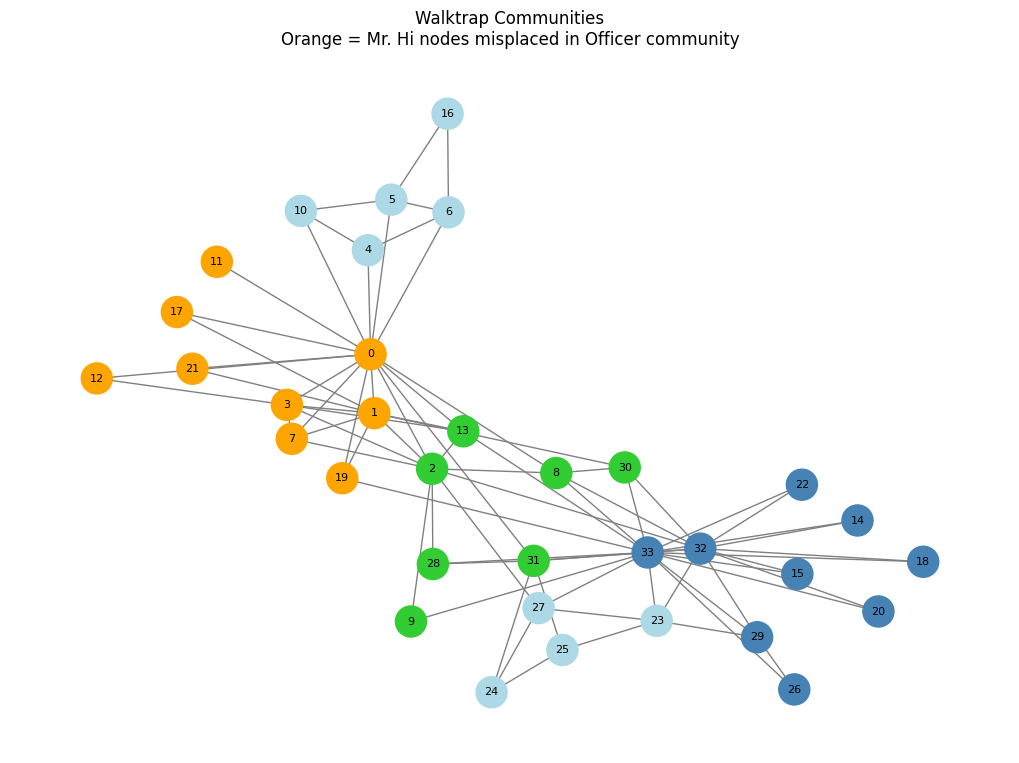

Mr. Hi nodes misplaced in Officer community: [0, 1, 3, 7, 11, 12, 17, 19, 21]
Number of misclassified nodes: 9


In [10]:
community_colors = []
for node in G.nodes():
  if node in walktrap.communities[0]: # This is the mixed community
    if ground_truth[node] == "Mr. Hi":
      community_colors.append("orange") # misclassified Mr. Hi
    else: # ground_truth[node] == "Officer"
      community_colors.append("tomato") # correct John A
  elif node in walktrap.communities[1]: # This community is entirely Mr. Hi
    community_colors.append("steelblue") # correct Mr. Hi
  elif node in walktrap.communities[2]: # This community is entirely Officer
    community_colors.append("limegreen") # correct John A
  else: # This implicitly means node in louvain.communities[3], which is also Mr. Hi
    community_colors.append("lightblue") # correct Mr. Hi sub-group

plt.figure(figsize=(10,7))
nx.draw(G, pos, node_color=community_colors, with_labels=True, node_size=500, edge_color="gray", font_size=8)
plt.title("Walktrap Communities\nOrange = Mr. Hi nodes misplaced in Officer community")
plt.show()

# identify exactly which Mr. Hi nodes are in the mixed communtiy
misclassified = [n for n in walktrap.communities[0]
                 if ground_truth[n] == "Mr. Hi"]
print(f"Mr. Hi nodes misplaced in Officer community: {misclassified}")
print(f"Number of misclassified nodes: {len(misclassified)}")

## **Step 7: Final comparison plot with all three methods**

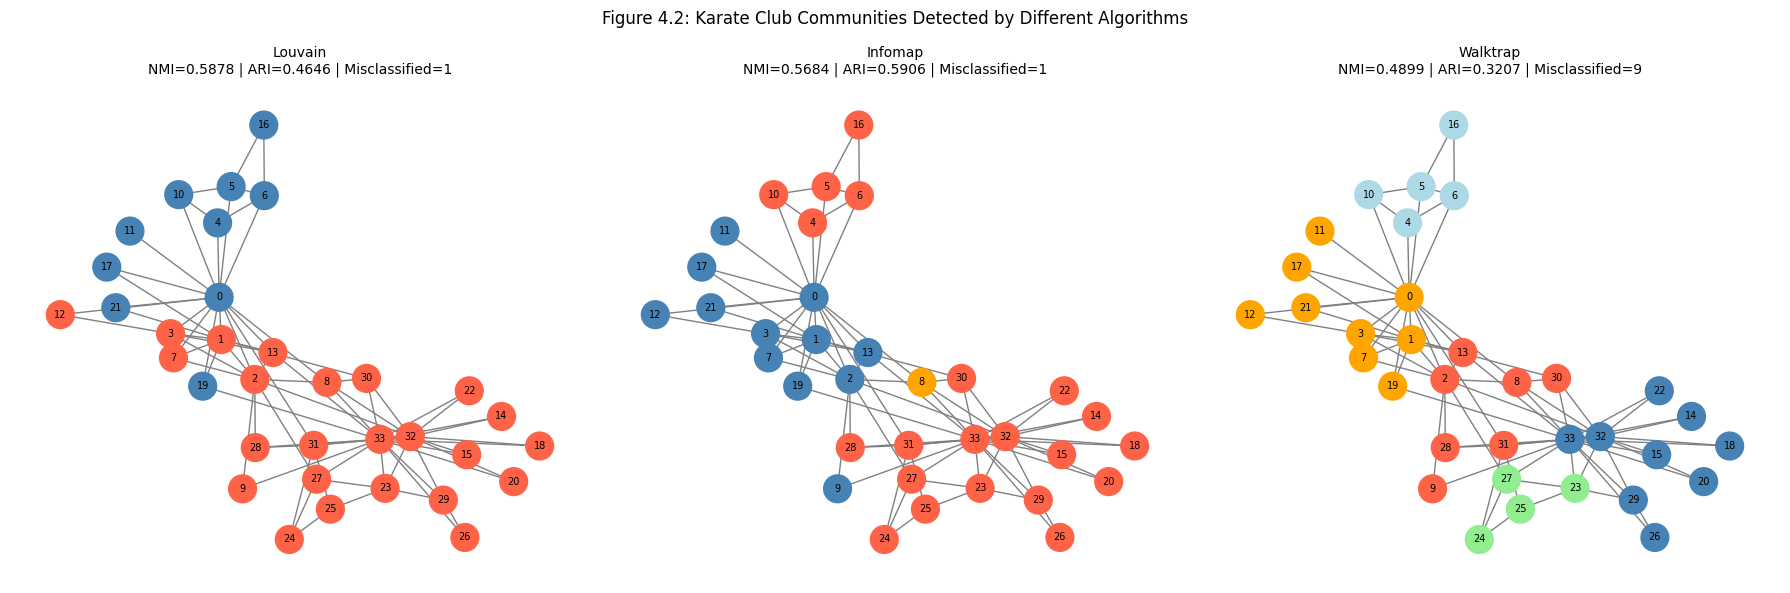

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods_data = [
    (louvain,  "Louvain\nNMI=0.5878 | ARI=0.4646 | Misclassified=1"),
    (infomap,  "Infomap\nNMI=0.5684 | ARI=0.5906 | Misclassified=1"),
    (walktrap, "Walktrap\nNMI=0.4899 | ARI=0.3207 | Misclassified=9")
]

for ax, (method, title) in zip(axes, methods_data):
    # build colors
    color_map = []
    for node in G.nodes():
        # find which community this node belongs to
        node_community = None
        for i, comm in enumerate(method.communities):
            if node in comm:
                node_community = i
                break

        faction = ground_truth[node]
        # if node is in community 0 and is Mr. Hi -> misclassified
        if node_community == 0 and faction == "Mr. Hi":
            color_map.append("orange")
        elif node_community == 0:
            color_map.append("tomato")
        elif node_community == 1:
            color_map.append("steelblue")
        elif node_community == 2:
            color_map.append("tomato")
        elif node_community == 3:
            color_map.append("lightblue")
        else:
            color_map.append("lightgreen")

    nx.draw(G, pos, node_color=color_map,
            with_labels=True, node_size=400,
            edge_color="gray", font_size=7, ax=ax)
    ax.set_title(title, fontsize=10)

plt.suptitle("Figure 4.2: Karate Club Communities Detected by Different Algorithms")
plt.tight_layout()
plt.savefig('/content/figure_4_1_karate_communities.png', dpi=300, bbox_inches='tight')
plt.show()

## **Bar Visualization of NMI and ARI**

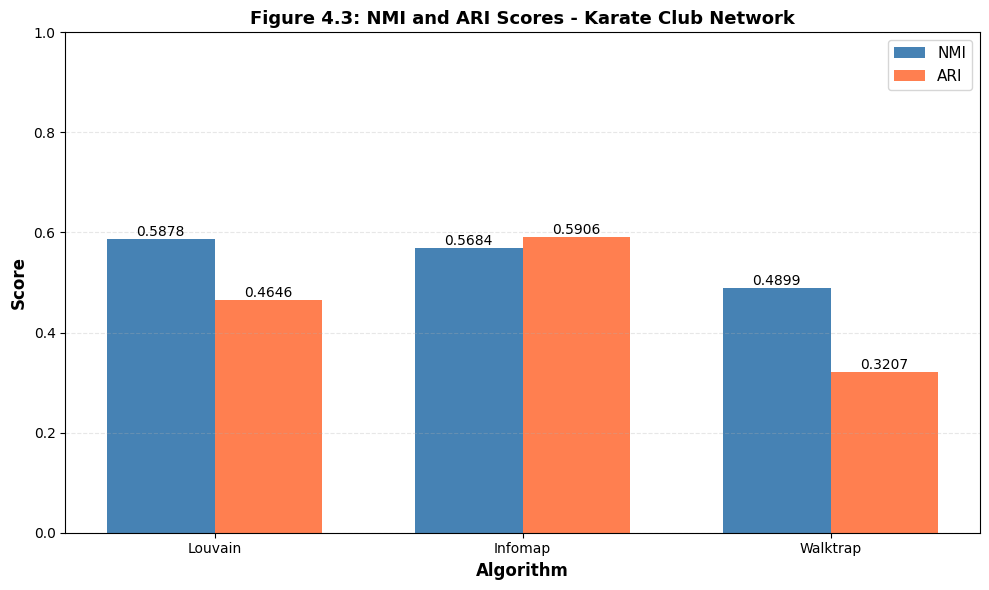

Figure 4.2 saved as 'figure_4_2_karate_nmi_ari.png'


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Karate Club experiment
algorithms = ['Louvain', 'Infomap', 'Walktrap']
nmi_scores = [0.5878, 0.5684, 0.4899]
ari_scores = [0.4646, 0.5906, 0.3207]

# Set up bar positions
x = np.arange(len(algorithms))
width = 0.35

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
bars1 = ax.bar(x - width/2, nmi_scores, width, label='NMI', color='steelblue')
bars2 = ax.bar(x + width/2, ari_scores, width, label='ARI', color='coral')

# Add labels and title
ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 4.3: NMI and ARI Scores - Karate Club Network',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(algorithms)
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/figure_4_2_karate_nmi_ari.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.2 saved as 'figure_4_2_karate_nmi_ari.png'")